# <font face="Verdana" size=6 color='#6495ED'>  IAD011 - APRENDIZADO POR REFORÇO

<font face="Verdana" size=3 color='#40E0D0'> Profs. Larissa Driemeier e Thiago Martins


<center><img src='https://drive.google.com/uc?export=view&id=1PoKxE7mE-pgBYahdjXJcfC1axNkIAYS9' width="600"></center>


__Livro texto:__

Richard S. Sutton and Andrew G. Barto, [Reinforcement learning : an introduction](https://web.stanford.edu/class/psych209/Readings/SuttonBartoIPRLBook2ndEd.pdf), The MIT Press, 2nd ed., 2018.


__Referências:__

Para compor este Notebook, foram usadas as seguintes referências, além do livro texto:
1.  Jeremy Zhang, [Reinforcement Learning — Generalisation in Continuous State Space](https://towardsdatascience.com/reinforcement-learning-generalisation-in-continuous-state-space-df943b04ebfa), 2019.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
import scipy.signal as signal
import copy
from tqdm import tqdm


## Funções Aproximadoras

O aprendizado por reforço clássico exige representações exatas das funções de valor e das políticas, o que limita sua aplicação a problemas menores e discretos. Entretanto, a maioria dos problemas do mundo real envolve variáveis com um número muito grande, ou até infinito, de possíveis valores — como no caso de variáveis contínuas.

Em espaços de estados discretos, teoricamente, um agente pode explorar todos os estados e descobrir as recompensas associadas a cada um. Porém, ao estendermos essa abordagem para espaços de estado contínuos, a ideia de "explorar todos os estados" se torna impraticável e, em muitos casos, impossível. Nessa situação, não basta apenas aplicar o aprendizado por reforço diretamente.

Para lidar com esse desafio, precisamos de métodos que generalizem a função de valor. Isso significa que, ao invés de trabalhar com cada estado de forma individual, passamos a aproximar as funções de valor valor $𝑣(𝑠)$ e $q(𝑠,𝑎)$ e as políticas, criando uma representação mais compacta e eficiente do estado.

$$
𝑣_𝜋 (𝑠) \approx \hat{v}(𝑠, \mathbf{w})
$$

$$
𝑞_𝜋 (𝑠,𝑎) \approx \hat{q}(𝑠,𝑎, \mathbf{w})
$$

Com essa abordagem, conseguimos aplicar o aprendizado por reforço em ambientes mais complexos e contínuos, onde seria inviável trabalhar com cada estado isoladamente. Existem diversos aproximadores de função, dentre os quais destacam-se:
* State aggregation
* Polinômios
* Fourier
* Radial Basis
* Coarse Coding
* Tile coding
* Redes neurais
* ...

A ideia parece boa, pois diminuímos o problema, uma vez que teremos menos pesos $𝒘$ do que temos estados $𝒔$ (reduzimos memória e tempo computacional).

Em vez de atualizar os valores $𝑣(𝑠)$ e $q(𝑠,𝑎)$ diretamente nas tabelas, usamos os métodos vistos, MC ou TD learning, para atualizar os pesos $𝒘$.

Como? É o que aprenderemos hoje.



**Objetivo**: encontrar o vetor de parâmetros $𝒘$ minimizando o erro quadrático médio entre o valor aproximado $\hat{v}$ e o valor verdadeiro $𝑣_𝜋$

$$
𝐽(𝒘) = \mathbb{E}_𝜋 \left[ (𝑣_𝜋(𝑠) − \hat{v}(𝑠, \mathbf{w}))^2 \right]
$$

A questão é: como? A resposta está no coração das técnicas de IA:  
**gradiente descendente!**



### Gradiente descendente estocástico (SGD)


\begin{align}
\textbf{w}_{t+1} &\stackrel{\text{def}}{=} \textbf{w}_t-\frac{1}{2}\alpha\nabla\left[v_\pi(S_t)-\hat{v}(S_t,\textbf{w}_t)\right]^2\\
 &=\textbf{w}_t+\alpha\left[v_\pi(S_t)-\hat{v}(S_t,\textbf{w}_t)\right]\nabla\hat{v}(S_t,\textbf{w}_t) \tag{1}
\end{align}
onde $\alpha$ é um parâmetro de tamanho de passo positivo e $\nabla\hat{v}(S_t,\textbf{w}_t)$ denota o vetor coluna de derivadas parciais da expressão em relação ao componentes do vetor $\textbf{w}_t$:
$$
\nabla\hat{v}(S_t,\textbf{w}_t) = \left[\frac{\partial \hat{v}(S_t,\textbf{w}_t)}{\partial w_0} \quad \frac{\partial \hat{v}(S_t,\textbf{w}_t)}{\partial w_1} \cdots \frac{\partial \hat{v}(S_t,\textbf{w}_t)}{\partial w_d} \right]^T \tag{2}
$$

Mas, lembrem-se, não conhecemos $v_\pi(S_t)$... Nesses casos não podemos realizar a atualização exata de (1), mas podemos aproximá-la substituindo $U_t$ no lugar de $v_\pi(S_t)$. Dessa forma, obtém-se o seguinte método geral SGD para previsão de valor de estado:
\begin{align}
\textbf{w}_{t+1} &\stackrel{\text{def}}{=} \textbf{w}_t+\alpha\left[U_t-\hat{v}(S_t,\textbf{w}_t)\right]\nabla\hat{v}(S_t,\textbf{w}_t)
\end{align}

Se $U_t$ é uma estimativa não viesada, isto é, se $\mathbb E[U_t|S_t=s] = v_\pi(s)$, para cada $t$, garante-se que $\textbf{w}_t$ converge para um ótimo local com a diminuição de $\alpha$, sob as condições usuais de aproximação estocástica,
$$
\sum_{n=1}^\infty\alpha_n(a) = \infty \qquad \sum_{n=1}^\infty\alpha_n^2(a) < \infty
$$
onde $\alpha_n(a)$ é a *taxa de aprendizado* ou tamanho do passo usado para processar a recompensa recebida após a n-ésima seleção da ação $a$. A primeira condição é necessária para garantir que os passos sejam grandes o suficiente para eventualmente superar quaisquer condições iniciais ou flutuações aleatórias. A segunda condição garante que eventualmente os passos se tornem pequenos o suficiente para assegurar a convergência.

Para Monte Carlo, por exemplo, $U_t \leftarrow G_t$. Dessa forma, a versão de gradiente descendente da previsão do valor de estado de Monte Carlo tem a garantia de encontrar uma solução localmente ótima.

Quando se utiliza bootstrapping como retornos de $𝑛$ passos, $U_t$ depende do valor atual do vetor dos pesos $𝒘_𝑡$. Os métodos de bootstrapping não são, de fato, exemplos de gradiente descendente e levam em conta o efeito da alteração do vetor de peso $𝒘_𝑡 $ na estimativa, mas ignoram seu efeito no alvo. Eles incluem apenas uma parte do gradiente e, consequentemente, os chamamos de métodos semi-gradiente.

Embora os métodos semi-gradientes (bootstrapping) não convergem tão robustamente quanto os métodos gradientes, eles convergem de forma confiável em casos importantes, como o caso linear, que veremos mais para frente.

###  Algoritmos com Aproximação de Função

####  MC (Monte Carlo)

Usa o **retorno total $G_t$** como alvo:

$$
\mathbf{w} \leftarrow \mathbf{w} + \alpha \left[ G_t - \hat{v}(s_t, \mathbf{w}) \right] \nabla_{\mathbf{w}} \hat{v}(s_t, \mathbf{w})
$$

Atualiza **após o episódio**, como já estudamos, não tem viés, mas **alta variância**.

#### TD(0)
Usa o alvo com 1 passo à frente:

$$
\mathbf{w} \leftarrow \mathbf{w} + \alpha \left[ r_{t+1} + \gamma \hat{v}(s_{t+1}, \mathbf{w}) - \hat{v}(s_t, \mathbf{w}) \right] \nabla_{\mathbf{w}} \hat{v}(s_t, \mathbf{w})
$$

E permite atualizar a cada passo. Tem menor variância, mas com **viés**.

#### TD(λ)
Combina MC e TD(0) com fator de decaimento $\lambda \in [0, 1]$. Usa **rastreamento de elegibilidade (eligibility traces)** (vide explicação a seguir) para propagar o erro ao longo dos estados visitados. Equilíbrio entre viés e variância:
  - $\lambda = 0$: vira TD(0)
  - $\lambda = 1$: aproxima MC



## TD(λ) com Traços de Elegibilidade

Para cada passo $ t $ do episódio:

1. __Erro temporal (TD-error):__
   $$
   \delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)
   $$

2. __Atualização do traço de elegibilidade__ (para todos os estados $ s $):
   $$
   e_t(s) =
   \begin{cases}
   \gamma \lambda \, e_{t-1}(s) + 1 & \text{se } s = S_t \quad \text{(estado visitado)} \\
   \gamma \lambda \, e_{t-1}(s) & \text{caso contrário}
   \end{cases}
   $$

3. __Atualização do valor de todos os estados__:
   $$
   V(s) \leftarrow V(s) + \alpha \, \delta_t \, e_t(s) \quad \forall s
   $$

## Exemplo Passo a Passo

<center><img src='https://drive.google.com/uc?export=view&id=1AXW53qbEOA33q3Glzq--6JQaknHicj4Z' width="600"></center>

Considere a sequência:

| Tempo (t) | Estado (Sₜ) | Recompensa (Rₜ₊₁) | Próximo Estado (Sₜ₊₁) |
|----------|------------|------------------|----------------------|
| 100      | S₁₀₀       | R₁₀₁             | S₁₀₁                 |
| 101      | S₁₀₁       | R₁₀₂             | S₁₀₂                 |
| 102      | S₁₀₂       | R₁₀₃             | S₁₀₃                 |
| 103      | S₁₀₃       | R₁₀₄             | S₁₀₄                 |

### Passo $ t = 100 $:
\begin{align*}
\delta_{100} &= R_{101} + \gamma V(S_{101}) - V(S_{100}) \\
e_{100}(S_{100}) &= \gamma \lambda \cdot 0 + 1 = 1 \quad \text{(outros } e_t(s) = 0) \\
V(S_{100}) &\leftarrow V(S_{100}) + \alpha \, \delta_{100} \cdot 1
\end{align*}

### Passo $ t = 101 $:
\begin{align*}
\delta_{101} &= R_{102} + \gamma V(S_{102}) - V(S_{101}) \\
e_{101}(S_{101}) &= 1, \quad e_{101}(S_{100}) = \gamma \lambda \\
V(S_{100}) &\leftarrow V(S_{100}) + \alpha \, \delta_{101} \cdot (\gamma \lambda) \\
V(S_{101}) &\leftarrow V(S_{101}) + \alpha \, \delta_{101} \cdot 1
\end{align*}

## Passo $ t = 102 $:
\begin{align*}
\delta_{102} &= R_{103} + \gamma V(S_{103}) - V(S_{102}) \\
e_{102}(S_{102}) &= 1, \quad e_{102}(S_{101}) = \gamma \lambda, \quad e_{102}(S_{100}) = (\gamma \lambda)^2 \\
V(S_{100}) &\leftarrow V(S_{100}) + \alpha \, \delta_{102} \cdot (\gamma \lambda)^2 \\
V(S_{101}) &\leftarrow V(S_{101}) + \alpha \, \delta_{102} \cdot (\gamma \lambda) \\
V(S_{102}) &\leftarrow V(S_{102}) + \alpha \, \delta_{102} \cdot 1
\end{align*}

## Funções lineares

Um dos casos especiais mais importantes de aproximadores de funções é aquele em que a função aproximada, $\hat v(s, \textbf w )$, é uma função linear do vetor peso, $\textbf w$:
$$
\hat v(s, \textbf w ) \stackrel{\text{def}}{=} \textbf w^T \textbf{x}(s) = \sum_{i=0}^d w_i x_i(s)
$$
onde $s$ é o estado. O vetor $\textbf{x}(s)$ é chamado de vetor de características (*features*) representando o estado $s$. Cada componente $x_i(s)$ de $\textbf{x}(s)$ é o valor de uma função $x_i : \mathcal S \rightarrow \mathbb{R}$.

## Agregação de estados (*State aggregation*)

Agregação de estados é a forma mais simples de aproximador de função, é um caso especial de função linear. Por exemplo, suponha que existam 10 estados (1, 2, 3, …, 10) no espaço, definimos 1 a 5 tem o mesmo valor e 6 a 10 tem outro valor, então isso é chamado de *agregação de estado*. A representação matemática poderia ser:

```
V(St) = w_0  se   1 ≤ St ≤ 5
V(St) = w_1  se   5 < St ≤ 10
```

A função é simples, mas muito importante, pois a ideia é crítica em Tile Coding, que é uma técnica de generalização de funções que está sendo muito utilizada em problemas de aprendizado por reforço e iremos estudar mais adiante. A vantagem da agregação de estado é que a derivada do estado em cada sessão agregada é 1 e o valor desse estado é o peso correspondente.

Por exemplo, se você tiver um espaço de estado com 1000 estados e os dividir em 10 grupos (qualquer semelhança com o próximo exercício é mera coincidência), cada um desses grupos terá 100 estados vizinhos. A função de aproximação será,
\begin{equation}
\hat v(s,\mathbf w) = x_1w_1 + x_2w_2 + ... + x_{10}w_{10}
\end{equation}
Quando você escolhe um estado, o vetor de características $\mathbf x$ será um vetor codificado com 1 que é colocado em uma posição que depende de qual grupo o estado escolhido pertence. Por exemplo, se você tiver o estado 990, esse estado pertence ao grupo 10, então o vetor $\mathbf x$ será,
\begin{equation}
\mathbf x_t = [0, 0, 0,0,0,0,0,0, 0, 1]^T
\end{equation}
o que isso significa que o único peso que será atualizado é o peso $w_{10}$ porque os gradientes para todos os outros pesos serão $0$.



### 1000 Steps Random Walk
<small>Fonte: Richard S. Sutton and Andrew G. Barto, Reinforcement Learning: An Introduction, 2nd ed, The MIT Press. Pág. 203, Exemplo 9.1.<small>

Considere uma versão de 1000 estados da tarefa de *Random Walk*. Os estados são numerados de 1 a 1000, da esquerda para a direita, e todos os episódios começam próximo ao centro, no estado 500. As possibilidades de transições de estado são do estado atual para um dos 100 estados vizinhos à sua esquerda, ou para um dos 100 estados vizinhos estados à sua direita, todos com igual probabilidade.

<center><img src='https://drive.google.com/uc?export=view&id=1uYQUEm85w22MgYyYP3NqaNQEqY5HFkv5' width="800"></center>


Obviamente, se o estado atual estiver próximo de uma borda, pode haver menos de 100 vizinhos desse lado. Nesse caso, toda a probabilidade que teria ido para esses vizinhos ausentes vai para a probabilidade de terminar naquele lado (portanto, o estado 1 tem 0,5 chance de terminar à esquerda e o estado 950 tem 0,25 chance de terminar no lado direito).

<center><img src='https://drive.google.com/uc?export=view&id=1KrtMZfRqvybh8_UIaXStkem052JhngQZ' width="800"></center>

Como de costume, término à esquerda produz uma recompensa de -1 e término à direita produz uma recompensa de +1. Todas as outras transições têm uma recompensa de zero.

Vamos abrir um parenteses aqui... Que tal calcular o valor real a partir da definição, aprendida no primeiro dia de aula? O que é valor???
\begin{equation}
\mathbf v_\pi = \mathcal R^{\pi}+\gamma \mathcal P^{\pi}\mathbf v_\pi
\end{equation}
ou seja,
\begin{equation}
\mathbf v_\pi = \left[ \mathbf I -\gamma \mathcal P^{\pi}\right]^{-1}\mathcal R^{\pi}
\end{equation}
onde, os elementos das matrizes $\mathcal R^{\pi}$ e $\mathcal P^{\pi}$ são, respectivamente,
\begin{align}
\mathcal R^{\pi}_s &= \sum_{a\in \mathcal A} \pi(a|s)\mathcal R_s^a \\
\mathcal P^{\pi}_s &= \sum_{a\in \mathcal A} \pi(a|s)\mathcal P_{ss'}^a
\end{align}

Usando o processo de decisão de Markov (MDP) cujas ações são definidas pela política $\pi$, podemos escrever a Equação de Bellman em forma matricial:

\begin{equation}
\begin{bmatrix}
v_1^\pi \\
v_2^\pi \\
\vdots \\
v_n^\pi
\end{bmatrix} =
\begin{bmatrix}
\mathcal R_1^\pi \\
\mathcal R_2^\pi \\
\vdots \\
\mathcal R_n^\pi
\end{bmatrix} + \gamma
\begin{bmatrix}
\mathcal P_{11}^\pi  & P_{12}^\pi & \cdots & P_{1n}^\pi\\
\mathcal P_{21}^\pi & P_{22}^\pi& \cdots & P_{2n}^\pi\\
\vdots \\
\mathcal P_{n1}^\pi & P_{n2}^\pi & \cdots & P_{nn}^\pi
\end{bmatrix}
\begin{bmatrix}
v_1^\pi \\
v_2^\pi \\
\vdots \\
v_n^\pi
\end{bmatrix}
\end{equation}


In [2]:
gamma = 0.99999999
number_states = 1002
jump_size = 100

###############
#### RECOMPENSA
###############

# AÇÃO PARA ESQUERDA
# veja que a recompensa de cada estado é proporcional à probabilidade
# de cair no estado terminal à esquerda multiplicado pela recompensa(-1)
reward_pi_left = [0]*number_states
for i in range (1,jump_size+1):
  pi_as = (jump_size - (i-1))/jump_size
  reward_pi_left[i] = -1*pi_as

# AÇÃO PARA DIREITA
# veja que a recompensa de cada estado é proporcional à probabilidade
# de cair no estado terminal à direita multiplicado pela recompensa(+1)
reward_pi_right = [0]*number_states
for i in range (number_states-2-jump_size,number_states-1):
  pi_as = (i - (number_states-2-jump_size))/jump_size
  reward_pi_left[i] = 1*pi_as

# PI
reward_pi = 0.5*np.array(reward_pi_left)+0.5*np.array(reward_pi_right)

###############
##### TRANSIÇÃO
###############

#AÇÃO PARA ESQUERDA
transition_pi_left = np.zeros((number_states,number_states))
for i in range(1,number_states-1):
  k = 0
  for j in range(i+1,min(i+101,number_states-1)):
    k += 1
    transition_pi_left[i][j]=1/jump_size
  if k<jump_size:
    transition_pi_left[i][number_states-1]=(jump_size-k)/jump_size

# AÇÃO PARA DIREITA
transition_pi_right = np.zeros((number_states,number_states))
for i in range(number_states-2,0,-1):
  k = 0
  for j in range(i-1,max(i-(jump_size+1),0),-1):
    k += 1
    transition_pi_right[i][j]=1/jump_size
  if k<100:
    transition_pi_right[i][0]=(jump_size-k)/jump_size

# PI
transition_pi = 0.5*np.array(transition_pi_left) + 0.5*np.array(transition_pi_right)
transition_pi[0][0] = 1.
transition_pi[number_states-1][number_states-1] = 1.


In [3]:
reward_pi


array([ 0.   , -0.5  , -0.495, ...,  0.495,  0.5  ,  0.   ], shape=(1002,))

In [4]:
reward_pi[200]


np.float64(0.0)

In [5]:
print(transition_pi[950])


[0.    0.    0.    ... 0.005 0.005 0.25 ]


In [6]:
transition_pi[1]


array([0.5  , 0.   , 0.005, ..., 0.   , 0.   , 0.   ], shape=(1002,))

In [7]:
true_values = np.linalg.inv(np.identity(number_states)-gamma*np.array(transition_pi)).dot(reward_pi)


In [8]:
true_values = true_values[1:-1]


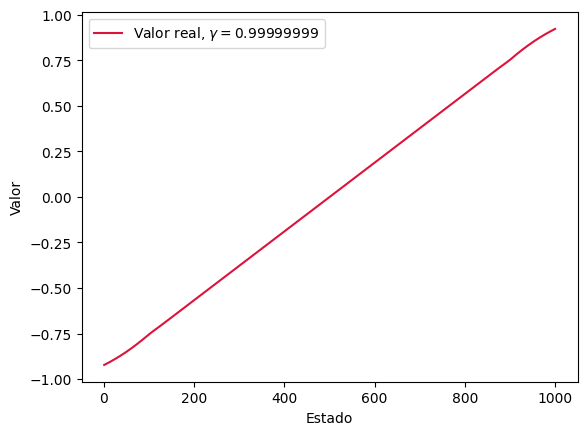

In [9]:
x_value = range(1, number_states-1)

plt.plot(x_value, true_values, color = 'crimson', label=r"Valor real, $\gamma=$"+str(gamma));
plt.xlabel('Estado');
plt.ylabel('Valor');
plt.legend();


O **código n-step semi-gradiente TD** para estimar funções de valor usando agregação aproximada de estados aplica aprendizado por diferença temporal com bootstrapping de n passos. Esse método estima a função de valor $ V(s) $, aproximando o valor do estado usando funções parametrizadas em vez de uma tabulação exata.

Sabe-se que na **agregação de estados**, múltiplos estados são agrupados, e um único valor aproximado é aprendido para cada grupo ou cluster, em vez de aprender individualmente para cada estado. Isso reduz o número de atualizações de valores e a quantidade de memória necessária para espaços de estados grandes. Normalmente, um **vetor de pesos (w)** ou **vetor de parâmetros** é usado para armazenar o valor aproximado para cada grupo de estados.

Lembre-se que o aprendizado por **TD de n passos** é um método de diferença temporal (TD) que atualiza a função de valor após observar uma sequência de recompensas ao longo de **n passos**. Isso é um compromisso entre os métodos de Monte Carlo (que utilizam o retorno total após o fim do episódio) e métodos TD de um passo (que atualizam após cada passo). Nos métodos de n passos, a atualização é baseada no retorno observado após n passos, mas ainda é feito bootstrapping usando uma estimativa da função de valor no estado final da sequência.

<center><img src='https://drive.google.com/uc?export=view&id=1gVZEF9c26UIq7alh8unXfoCQxX-Bod2e' width="600"></center>Fonte: Richard S. Sutton and Andrew G. Barto, Reinforcement Learning: An Introduction, 2nd ed, The MIT Press.
Pág. 142

O *target* para uma atualização arbitrária de n-steps é o retorno de $n$ etapas:
$$
G_{t:t+n} \stackrel{\text{def}}{=} R_{t+1}+\gamma  R_{t+2}+\cdots+\gamma^{n-1}  R_{t+n}+\gamma^n V_{t+n-1}\left(S_{t+n}\right)
$$
para todo $n,t$ tal que $n \geq 1$ e $0 \leq t \leq T-n$, onde $T$ é o tamanho (número de etapas) do episódio. Todos os retornos de n steps podem ser considerados aproximações do retorno completo, truncados após $n$ passos e então corrigidos para os termos faltantes restantes por $V_{t+n-1}\left(S_{t+n}\right)$. Se $t + n \geq T$ (se o retorno de $n$ etapas se estender até ou além do término do episódio), todos os termos ausentes serão considerados como zero e o retorno de $n$ etapas definido como igual ao retorno completo comum ($G_{t:t+n} = G_t$ se $t + n \geq T$).

Por último, sabe-se que o método de **semi-gradiente** usa gradiente descendente, mas apenas parcialmente atualiza os pesos (ou seja, os parâmetros da aproximação da função de valor) com base no erro TD. A equação chave da implementação é:

$$
\textbf{w}_{t+n} =\textbf{w}_{t+n-1}+\alpha\left[G_{t:t+n}-\hat{v}(S_t,\textbf{w}_t)\right]\nabla\hat{v}(S_t,\textbf{w}_{t+n-1}), \qquad (0 \leq t<T)
$$

O pseudo código é mostrado na figura abaixo.

<center><img src='https://drive.google.com/uc?export=view&id=1LDTh43_suox3UAcvjIe6cx2PFLyz218o' width="600"></center>Fonte: Richard S. Sutton and Andrew G. Barto, Reinforcement Learning: An Introduction, 2nd ed, The MIT Press.
Pág. 209
   
### Resumo do Código

O código implementa os seguintes passos:

1. **Inicialização de parâmetros**:
   - Um conjunto de parâmetros (pesos) $\textbf{w} $ correspondente à função de valor aproximada.
   - Escolher $ n $, o número de passos para o aprendizado TD de n passos.
   - Definir a **taxa de aprendizado** $ \alpha $ e o fator de desconto $ \gamma $ para recompensas futuras.

2. **Loop de Episódio**:
   - Para cada episódio, inicializa-se o estado inicial.
   - Para cada passo $ t $, armazenam-se recompensas e estados para futuros retornos de n-passos.

3. **Cálculo do Retorno de n-passos**:
   - Calcula-se o retorno $ G_{t:t+n} $, que requer o acompanhamento das recompensas e estados ao longo dos últimos $n $ passos.

4. **Atualização de Pesos**:
   - Após observar $ n $ passos, o vetor de pesos $\textbf{w} $ é atualizado usando a fórmula de semi-gradiente. O erro TD  é usado para corrigir a aproximação com base no retorno observado.

5. **Bootstrapping**:
   - Como o **bootstrapping** é utilizado, o aprendizado não espera o fim do episódio para atualizar os valores, tornando-o mais eficiente em cenários de aprendizado online.

In [10]:
num_states = 1002  # número de estados
start_state = 500        # início
terminal_0 = 0            # estado terminal à esquerda
terminal_1 = 1001         # estado terminal à direita

# valores reais de cada estado armazenados em true_value (length = 1002)
true_values = np.arange(-1001, 1003, 2) / 1001.0


In [11]:
class AggValueFunction:

    def __init__(self, num_groups=10):
        self.num_groups = num_groups
        self.group_size = num_states // self.num_groups
        self.values = np.zeros(self.num_groups)

    def value(self, state):
        # valor do estado final
        if state == terminal_0:
            return 0
        if state == terminal_1:
            return 0
        group = (state - 1) // self.group_size
        value = self.values[group]
        return value

    def update(self, delta, state):
        dev = 1                                 # derivada é 1 em state aggregation
        group = (state - 1) // self.group_size
        self.values[group] += delta*dev


In [12]:
class RandomWalk:

    def __init__(self, step=1, lr=2e-5, gamma=1, debug=True):
        self.state = start_state                       # estado inicial
        self.actions = ["left", "right"]               # ações possíveis
        self.end = False                               # fim de episódio
        self.n = step                                  # número de steps para atualização
        self.lr = lr                                   # taxa de aprendizado
        self.gamma = gamma                             # taxa de desconto
        self.debug = debug                             # debug

    def chooseAction(self):
      # escolhe entre ação para direita ou esquerda
        action = np.random.choice(self.actions)
        return action

    def takeAction(self, action):
        # escolhe entre 1-100 steps
        steps = np.random.choice(range(1, 101))
        if action == "left":
            state = self.state - steps
        else:
            state = self.state + steps
        # verifica se encontra-se em um estado terminal
        if state <= terminal_0 or state >= terminal_1:
          # se está em estado terminal, fim de episódio
            self.end = True
            if state <= terminal_0:
                state = terminal_0
            else:
                state = terminal_1
        # atualiza estado
        self.state = state
        return state

    def giveReward(self):
      # recompensas nos estados terminais
        if self.state == terminal_0:
            return -1
        if self.state == terminal_1:
            return 1
        return 0

    def reset(self):
      # começa um novo episódio
        self.state = start_state
        self.end = False

    def play(self, valueFunction, episodes=1e5):
        # loop sobre o número de episódios
        for epd in range(episodes):
            self.reset()
            # contador de tempo t= 0 e contador de passos até final do episódio T = infinito
            t = 0
            T = np.inf
            action = self.chooseAction()

            actions = [action]
            states = [self.state]
            rewards = [0]
            # loop para cada instante de tempo até o fim do episódio
            while True:
                if t < T:                            # T só assume valor diferente de infinito quando o estado terminal é alcançado
                    state = self.takeAction(action)  # proximo estado
                    reward = self.giveReward()       # recompensa

                    states.append(state)
                    rewards.append(reward)

                    if self.end:
                        if self.debug:
                            if (epd+1) % 5000 == 0:
                                print("Episódio {}: Finalizou em estado terminal {} | Número de estados percorridos {}".format(epd+1, state, len(states)))
                        T = t+1
                    else:
                        action = self.chooseAction() # já sabemos se a próxima ação será esquerda ou direita
                        actions.append(action)
                # tau é o instante de tempo cuja estimativa do estado está sendo atualizada
                tau = t - self.n + 1

                if tau >= 0: # se tau >= 0, já andei n steps para frente de tau, e agora atualizo o estado tau
                    G = 0
                    for i in range(tau+1, min(tau+self.n+1, T+1)):
                        G += np.power(self.gamma, i-tau-1)*rewards[i]
                    if tau+self.n < T:
                        state = states[tau+self.n]
                        G += np.power(self.gamma, self.n)*valueFunction.value(state)
                    # update value function
                    state = states[tau]
                    delta = self.lr*(G - valueFunction.value(state))
                    valueFunction.update(delta, state)

                if tau == T-1:
                    break

                t += 1


In [13]:
rw = RandomWalk(step=1, lr=0.001, gamma=1.0)
vFunc = AggValueFunction(num_groups=10)


In [14]:
rw.play(episodes=30000, valueFunction=vFunc)


Episódio 5000: Finalizou em estado terminal 0 | Número de estados percorridos 102
Episódio 10000: Finalizou em estado terminal 1001 | Número de estados percorridos 56
Episódio 15000: Finalizou em estado terminal 0 | Número de estados percorridos 49
Episódio 20000: Finalizou em estado terminal 0 | Número de estados percorridos 107
Episódio 25000: Finalizou em estado terminal 0 | Número de estados percorridos 71
Episódio 30000: Finalizou em estado terminal 0 | Número de estados percorridos 248


In [15]:
def plot_fig(func):
    x_value = range(1, 1001)
    states_value = []
    for i in x_value:
        states_value.append(func.value(i))
    plt.figure(figsize=[8, 6])
    plt.plot(x_value, states_value, color = 'navy', label="Valor aproximado, $\gamma=$"+str(rw.gamma))
    x_value = range(0, 1002)
    plt.plot(x_value, true_values, color = 'crimson', label=r"Valor real, $\gamma=1$")
    plt.xlabel('Estado')
    #plt.xlim(1,1001)
    plt.ylim(-1,1)
    plt.ylabel('Valor')
    plt.legend()


<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
C:\Users\mathe\AppData\Local\Temp\ipykernel_11828\2618290365.py:7: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(x_value, states_value, color = 'navy', label="Valor aproximado, $\gamma=$"+str(rw.gamma))


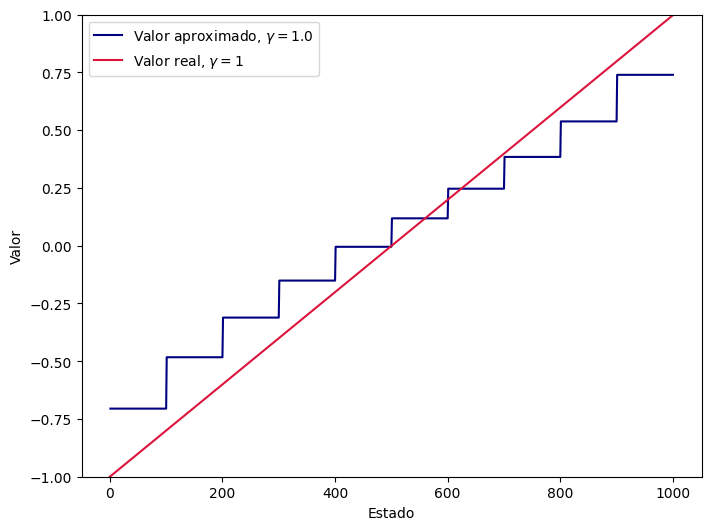

In [16]:
plot_fig(vFunc)


O efeito mais visível da distribuição está nos grupos mais à esquerda, cujos valores são claramente deslocados acima da média não ponderada dos valores verdadeiros dos estados dentro do grupo, e nos grupos mais à direita, cujos valores são claramente deslocados para baixo. Isso ocorre porque os estados nessas áreas têm a maior assimetria em suas ocorrências. Por exemplo, no grupo mais à esquerda, o valor do estado 100 tem um peso maior do que o estado 1 (ocorre mais vezes). Assim, a estimativa para o grupo é enviesada para o valor verdadeiro do estado 100, que é maior do que o valor verdadeiro do estado 1.

## <font face="Verdana" size=6 color='#6495ED'> Para você entregar - Parte I

Use MC (simplifique a classe `RandomWalk`) e encontre valores como:
<center><img src='https://drive.google.com/uc?export=view&id=1bOlMONkTVfxa3pbSzkQTaGD8UFKePwr-' width="600"></center>
<small>Fonte: Richard S. Sutton and Andrew G. Barto, Reinforcement Learning: An Introduction, 2nd ed, The MIT Press.
Pág. 204<small>


Explique proque os resultados são melhores.

## Polinômio

Suponha que um problema tenha estados com duas dimensões numéricas. Para um único estado representativo $s$, sejam seus dois números $s_1,s_2 \in \mathbb R$.
Você pode optar por representar $s$ simplesmente por suas duas dimensões de estado, de modo que
$$
𝑥(𝑠)=\left[s_1 \quad s_2 \right]^𝑇
$$
As restrições são:
* não poderá levar em consideração nenhuma interação entre essas dimensões;
* $s_1,s_2$  forem zero, o valor aproximado também terá que ser zero.

Ambas as limitações podem ser superadas representando $s$ pelo vetor de característica,
$$
𝑥(𝑠)=\left[1 \quad s_1 \quad s_2 \quad s_1s_2 \right]^𝑇
$$
ou ainda
$$
𝑥(𝑠)=\left[1 \quad s_1 \quad s_2 \quad s_1s_2 \quad s_1^2 \quad s_2^2 \right]^T
$$

Ou seja, de forma genérica, o conjunto de características pode ser definido por um polinômio, completo ou não, de ordem $k$.

Você pode fazer uso do uso do pré processador ...

`from sklearn.preprocessing import PolynomialFeatures`

In [17]:
# dados quaisquer
data = np.array([[1,2],[2,3],[3,4]])
print(data)
# transformação do conjunto de dados em características polinomiais
trans = PolynomialFeatures(degree=2)
data = trans.fit_transform(data)
print(data)


[[1 2]
 [2 3]
 [3 4]]
[[ 1.  1.  2.  1.  2.  4.]
 [ 1.  2.  3.  4.  6.  9.]
 [ 1.  3.  4.  9. 12. 16.]]


## Série de Fourier

A transformação mais comum usada no domínio da frequência é a de Fourier. Jean Baptiste Joseph Fourier (francês, que viveu de 1768 a 1830) apresentou, em 1807, ao Instituto de França, uma ideia, no mínimo, intrigante:

*Qualquer função periódica pode ser reescrita como uma soma ponderada de senos e cossenos de diferentes frequências.*

A transformação de Fourier é usada para converter um sinal qualquer em uma soma infinita de ondas senoidais. Uma vez que a análise de funções senoidais mostra outra perspectiva no estudo de funções generalizadas, esse método é muito útil e amplamente utilizado.

Série de Fourier pode ser analisada como um prisma que divide a luz do sol em seus componentes de cores. As cores diferentes que saem do prisma são componentes de frequência da luz branca do sol. No domínio do tempo, você vê a soma de todos os componentes de frequência. Você não pode separá-las, filtrá-las ou suprimi-las no domínio do tempo. Então, para análise de sinal, o domínio da freqüência é muito necessário.

Agora, quais são os ingredientes de que precisamos para aproximar uma função com uma série de Fourier? Uma função limitada periódica $x(t)$, com período $T$ que satisfaça as condições de Dirichlet, ié, ao longo do período,
1. $|x(t)|$ deve ser integrável;
2.  $x(t)$ deve ter um número finito de descontinuidades;
3. $x(t)$ deve ter um número finito de máximos e mínimos.
pode ser decomposta em série de Fourier.

Se as condições acima forem atendidas, podemos escrever a equação de síntese da seguinte maneira

\begin{equation}
	y(t) = \frac{a_0}{2} +  \sum_{n = 1}^{\infty} a_n \cos(\omega_n t) + b_n \sin(\omega_n t)
\end{equation}
ou
\begin{equation}
	y(t)=\frac{a_0}{2}+\sum_{n=1}^\infty \left[ a_n \cos\left(n\frac{2\pi}{T}t \right) +b_n \sin\left(n\frac{2\pi}{T}t \right) \right]
\end{equation}

dado que $\omega_n = n \omega_0=2\pi n/T$, onde $\omega_0$ é a frequência fundamental e $T$ o período fundamental. Observe que esta é uma soma infinita. Não podemos adicionar infinitos termos, mas quanto mais termos forem considerados, melhor será a aproximação.

Os coeficientes que resumem as equações de análise
\begin{equation}
\begin{split}
\omega_n &= {2\pi n \over T} \\
	a_0 &= {2 \over T}\int^{T}_{0} y(t) dt \\
	a_n &= {2 \over T}\int^{T}_{0} y(t) \cos(\omega_n t) dt\\
	b_n &= {2 \over T}\int^{T}_{0} y(t) \sin(\omega_n t) dt\\
\end{split}
\end{equation}

Em Aprendizado por Reforço, costuma-se utilizar a função aproxiamdora,
$$
x_i(s) = \cos \left(i\pi s\right), s \in [0,1]
$$
e o treinamento dos pesos definirá o problema no domínio da frequência.


## Onda quadrada

Pode-se deduzir que uma onda quadrada definida como,
\begin{equation} x(t) =
\left\{
\begin{array}{l l}
 1 \text{ se } t<T/2 \\
 -1 \text{ se } t \ge T/2
\end{array}
\right.
\end{equation}
e
\begin{equation} x(t+nT) = x(t)
\end{equation}

pode ser decomposta em série de Fourier como,
\begin{equation}
x(t) = \sum_{n=1}^{\infty}\frac{2}{n\pi} \left[1-(-1)^n\right]\sin(n \pi t)
\end{equation}

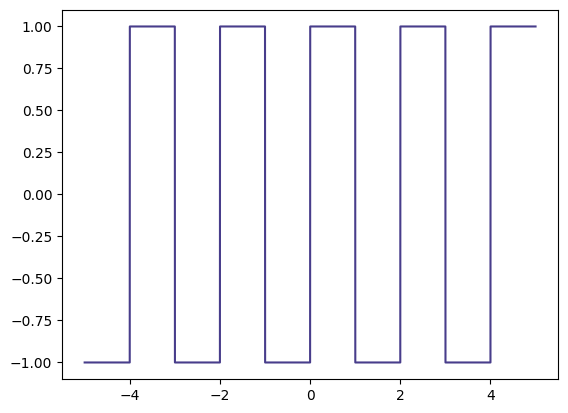

In [18]:
w=1/2
t = np.arange(-5, 5, 1/10000)
# Plotagem da onda quadrada
SquareWave = signal.square(2*np.pi* w*t)
plt.plot(t, SquareWave ,linewidth = 1.5, color = 'darkslateblue');


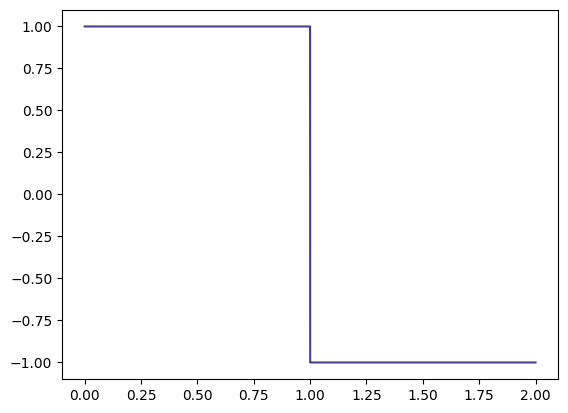

In [19]:
#1 período
T=1/w
Fs=10000
t_period = np.arange(0, T, 1/Fs)
period = signal.square(2*np.pi* w*t_period)
plt.plot(t_period, period,linewidth = 1.5, color = 'darkslateblue');


In [20]:
harmonicos = [20,50,100,1000]
bn = [2.*(1-(-1)**i)/(i*np.pi) for i in range(1,max(harmonicos)+1)]
T=1/w
Fs = 1000
t_period = np.arange(0, T, 1/Fs)
period = signal.square(2*np.pi* w*t_period)
x = []
for n in harmonicos:
  k1 = 1
  aux = [0. ]*len(t_period)
  while k1 < n+1:
    for k2 in range(len(t_period)):
      aux[k2] = aux[k2] + bn[k1-1]*np.sin(k1*np.pi*t_period[k2])
    k1 += 1
  x.append(aux)
x=np.array(x)


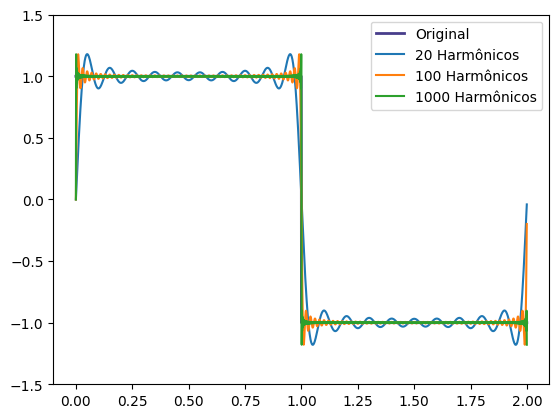

In [21]:
plt.plot(t_period, period, linewidth = 2, color = 'darkslateblue', label='Original')
plt.plot(t_period, x[0,:], label='20 Harmônicos')
plt.plot(t_period, x[2,:], label='100 Harmônicos')
plt.plot(t_period, x[3,:], label='1000 Harmônicos')
plt.ylim(-1.5,1.5)
plt.legend()
plt.show()


## <font face="Verdana" size=6 color='#6495ED'> Para você entregar - Parte II


1. Resolva o problema de *1000 Steps Random Walk*, mas, ao invés de agregação de valores, utilize as versões lineares, polinomial e Fourier. Use bases polinomiais de ordem 5, 10 e 20.

Use MC e ajuste os parâmetros de tamanho de passo ($\alpha$) para cada caso. Sugestão: $\alpha = 0,0001$ para a base polinomial e $ \alpha = 0,00005$ para a base de Fourier. Uma sugestão de leitura: [link](https://users.cs.duke.edu/~parr/jmlr03.pdf).

Você deve chegar a valores semelhantes ao apresentado no livro texto.

<center><img src='https://drive.google.com/uc?export=view&id=1vD0PSP-JSoM-uOdyFJ2o3gIy2OtlkMPD' width="600"></center>Fonte: Richard S. Sutton and Andrew G. Barto, Reinforcement Learning: An Introduction, 2nd ed, The MIT Press.
Pág. 214


O vetor de características é dado por um único valor que é definido como:
```
x(s) = s/num_states
```

Você deve criar uma nova classe,

In [23]:
import numpy as np

class LinearValueFunction:
    def __init__(self, order, method="poly"):
        if method == "poly":
            self.func = [lambda x, i=i: np.power(x, i) for i in range(order+1)]
        elif method == "fourier":
            self.func = [lambda x, i=i: np.cos(np.pi * x * i) for i in range(order+1)]
        self.weights = np.zeros(order+1)

    def value(self, state):
        phi = np.array([f(state) for f in self.func])
        return np.dot(self.weights, phi)

    def update(self, delta, state):
        phi = np.array([f(state) for f in self.func])
        self.weights += delta * phi


## Coarse Coding e Tile Coding

Se treinamos em um estado $𝑠$, os parâmetros $𝑤_𝑖$ de todos as regiões que interceptam o estado $𝑠$ serão afetadas, com efeito maior quanto mais regiões um estado tiver "em comum" com $𝑠$. *Coarse coding* é caracterizado por círculos que se sobrepõem, enqquanto *tile coding* é uma forma de *coarse coding* particularmente adequada para uso em algoritmos e para aprendizado on-line eficiente, conforme ilustra a figura abaixo.


<center><img src='https://drive.google.com/uc?export=view&id=1YvVRuoIm6mWT-OlYk-P90bmH8RzerZti' width="600"></center>

Para criar as *regiões* de características, precisamos saber:

Os principais parâmetros são:

- **`feature_ranges`**: Uma lista contendo os intervalos para cada *feature* (ou variável de estado). Por exemplo, se você tem duas *features* (como posição $x$ e velocidade $y$), cada intervalo define os valores mínimos e máximos que essas *features* podem ter. Se x: [-1, 1], y: [2, 5] então, [[-1, 1], [2, 5]]
  
- **`number_tilings`**: O número de *tilings* (grades) que você deseja criar. Essas grades são usadas para fornecer representações sobrepostas do espaço de estados. Por exemplo: 3 tilings

- **`bins`**: Uma lista com a configuração dos bins para cada *tiling*. Os bins determinam quantas subdivisões (tiles) são usadas em cada dimensão para cada *tiling*. Por exemplo: [[10, 10], [10, 10], [10, 10]]: 3 tilings * [x_bin, y_bin]

- **`offsets`**: Uma lista de deslocamentos para cada *tiling*. Os deslocamentos deslocam ligeiramente cada *tiling* para que elas se sobreponham, criando uma representação mais diversa do espaço de estados. Por exemplo: [[0, 0], [0.2, 1], [0.4, 1.5]]: 3 tilings * [x_offset, y_offset]

Veja, por exemplo, o código abaixo, extraído do [link](https://towardsdatascience.com/reinforcement-learning-tile-coding-implementation-7974b600762b).

A função `create_tiling` recebe um intervalo de uma característica dado por `feat_range` e o divide igualmente em `bins` partes e soma um deslocamento `offset` ao grid final.

In [33]:
def create_tiling(feat_range, bins, offset):
    return np.linspace(feat_range[0], feat_range[1], bins+1)[1:-1] + offset


In [34]:
bins = 10

feat_range1 = [-1.0, 1.0]
offset1 = 0.2

feat_range2 = [2., 5.0]
offset2 = 1.0

tiling_feat1 = create_tiling(feat_range1, bins, offset1)
tiling_feat2 = create_tiling(feat_range2, bins, offset2)
print(np.array_str(tiling_feat1, precision=1, suppress_small=True))
print(np.array_str(tiling_feat2, precision=1, suppress_small=True))


[-0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]
[3.3 3.6 3.9 4.2 4.5 4.8 5.1 5.4 5.7]


No tile coding, é possível que os valores extremos (dimensão inferior e superior) não sejam representados de maneira explícita. Isso ocorre porque o primeiro tile cobre valores que vão desde $-\infty$ até o primeiro valor relevante da divisão do espaço.

O espaço contínuo é dividido em múltiplos tiles (subdivisões), cada um correspondendo a um intervalo de valores. No entanto, esses tiles precisam cobrir todo o espaço, inclusive valores muito pequenos ou muito grandes que não são diretamente observados.

Por isso, o primeiro tile geralmente cobre todos os valores menores que o segundo valor da divisão. Ou seja, qualquer valor que esteja abaixo desse limite (teoricamente até $-\infty$) será considerado parte do primeiro tile. Na prática, isso significa que a dimensão inferior é descartada, já que o primeiro tile abrange qualquer valor menor que o segundo valor da divisão.

Exemplo: Se os valores da divisão dos tiles são $[a, b, c, d]$, o primeiro tile cobre o intervalo $[-\infty, a]$, o segundo cobre $[a, b]$, e assim por diante. Dessa forma, não é necessário definir explicitamente a dimensão inferior.

Da mesma forma, o último tile cobre o intervalo que vai desde o último valor da divisão até $+\infty$. Isso significa que qualquer valor maior que o limite superior da última divisão ainda será capturado pelo último tile. Assim, a dimensão superior também é descartada.

Exemplo: Se o último valor da divisão for $d$, o último tile cobriria o intervalo $[d, +\infty]$. Portanto, qualquer valor acima de $d$ será considerado parte desse último tile.

O motivo para essa abordagem é garantir que o espaço contínuo seja completamente coberto pelos tiles, sem lacunas. Assim, mesmo que um valor esteja fora do intervalo definido pelos limites explícitos, ele ainda será considerado parte de um tile. Isso evita a necessidade de tratar separadamente valores extremos, como $-\infty$ ou $+\infty$, e simplifica a estrutura da divisão.

<center><img src='https://drive.google.com/uc?export=view&id=1ccUSZDkPMs3FG6PK9Hck8WQ-xnhgngnG' width="600"></center>

A função abaixo gera múltiplas *tilings* (grades) para um espaço de estados contínuo.

Para cada dimensão da feature (`feat_i` em `range(len(feature_ranges))`), obtém o intervalo da feature (`feat_range`) e cria uma tiling para essa feature usando a função `create_tiling` (definida anteriormente). Esta função divide o intervalo da feature em bins com um deslocamento específico para criar os tiles dessa feature.


In [35]:
def create_tilings(feature_ranges, number_tilings, bins, offsets):
        tilings = []
        # for each tiling
        for tile_i in range(number_tilings):
            tiling_bin = bins[tile_i]
            tiling_offset = offsets[tile_i]

            tiling = []
            # for each feature dimension
            for feat_i in range(len(feature_ranges)):
                feat_range = feature_ranges[feat_i]
                # tiling for 1 feature
                feat_tiling = create_tiling(feat_range, tiling_bin[feat_i], tiling_offset[feat_i])
                tiling.append(feat_tiling)
            tilings.append(tiling)
        return np.array(tilings)


Vamos testar...

In [36]:
feature_ranges = [[-1, 1], [2, 5]]  # 2 características
number_tilings = 3
bins = [[10, 10], [10, 10], [10, 10]]  # cada tiling é uma garde 10x10
offsets = [[0, 0], [0.2, 1], [0.4, 1.5]]

tilings = create_tilings(feature_ranges, number_tilings, bins, offsets)

print(tilings.shape)  # # de tilings X características X bins
print(np.array_str(tilings, precision=1, suppress_small=True))


(3, 2, 9)
[[[-0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8]
  [ 2.3  2.6  2.9  3.2  3.5  3.8  4.1  4.4  4.7]]

 [[-0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]
  [ 3.3  3.6  3.9  4.2  4.5  4.8  5.1  5.4  5.7]]

 [[-0.4 -0.2  0.   0.2  0.4  0.6  0.8  1.   1.2]
  [ 3.8  4.1  4.4  4.7  5.   5.3  5.6  5.9  6.2]]]


Com a imagem, entenda como achar onde está o Wazawski em cada camada.
<center><img src='https://drive.google.com/uc?export=view&id=1CLzdjJQ9yor9IAOnkst0Bba_uVtMhLl-' width="300"></center>



In [37]:
feature = [0.1,2.5]
print(tilings)
for i,til in enumerate(tilings):
    coding0 = np.digitize(feature[0], til[0])
    coding1 = np.digitize(feature[1], til[1])
    print('tiling:',i,'bin:',coding0,coding1)


[[[-8.00000000e-01 -6.00000000e-01 -4.00000000e-01 -2.00000000e-01
    0.00000000e+00  2.00000000e-01  4.00000000e-01  6.00000000e-01
    8.00000000e-01]
  [ 2.30000000e+00  2.60000000e+00  2.90000000e+00  3.20000000e+00
    3.50000000e+00  3.80000000e+00  4.10000000e+00  4.40000000e+00
    4.70000000e+00]]

 [[-6.00000000e-01 -4.00000000e-01 -2.00000000e-01  5.55111512e-17
    2.00000000e-01  4.00000000e-01  6.00000000e-01  8.00000000e-01
    1.00000000e+00]
  [ 3.30000000e+00  3.60000000e+00  3.90000000e+00  4.20000000e+00
    4.50000000e+00  4.80000000e+00  5.10000000e+00  5.40000000e+00
    5.70000000e+00]]

 [[-4.00000000e-01 -2.00000000e-01  1.11022302e-16  2.00000000e-01
    4.00000000e-01  6.00000000e-01  8.00000000e-01  1.00000000e+00
    1.20000000e+00]
  [ 3.80000000e+00  4.10000000e+00  4.40000000e+00  4.70000000e+00
    5.00000000e+00  5.30000000e+00  5.60000000e+00  5.90000000e+00
    6.20000000e+00]]]
tiling: 0 bin: 5 1
tiling: 1 bin: 4 0
tiling: 2 bin: 3 0


## <font face="Verdana" size=6 color='#6495ED'> Para você entregar - Parte III

Você deve incorporar *tiling code* com método TD(0) (simplifique a classe `RandomWalk`) para resolver o problema dos *1000 Steps Random Walk*, gerando uma nova classe, chamada `TilingCodeFunction`,


In [38]:
class TilingCodeFunction:

    def __init__(self, bins, offset):
        self.bins = bins
        self.num_tilings = len(self.bins)
        self.tilings = []
        self.offset = offset
        for i, bin_size in enumerate(bins):
            coding = self._create_tiling(bin_size, offset[i])
            self.tilings.append(coding)
        self.weights = [np.zeros(bin_size) for bin_size in self.bins]

    def _create_tiling(self, bin_size, offset):
        return np.linspace(1, num_states-2, bin_size+1)[1:-1] + offset

    def value(self, state):
        total = 0.0
        for i, cuts in enumerate(self.tilings):
            idx = np.digitize(state, cuts)
            total += self.weights[i][idx]
        return total

    def update(self, delta, state):
        for i, cuts in enumerate(self.tilings):
            idx = np.digitize(state, cuts)
            self.weights[i][idx] += delta


Para essa nova classe, a entrada `bins` e `offset`, são vetores que contém, respectivamente, o número de divisões de cada camada e o offset de cada uma. Lembrem-se que o  problema é unidimensional, então, por exemplo, `bins = [10,25,50], offset=[0,50,100]` significa que serão produzidas 3 camadas, a primeira com o espaço dividido em 10 partes e sem offset, a segunda com o espaço dividido em 25 partes e offset de 50 e a terceira com espaço dividido em 50 partes e offset de 100.

Utilizando:
```
rw = RandomWalk(step=1, lr=0.001, gamma=1.0)
vFunc = TilingCodeFunction(bins = [10,25,50], offset=[0,50,100])
```
você deve chegar a um gráfico semelhante ao apresentado abaixo.



<center><img src='https://drive.google.com/uc?export=view&id=1rGZEIvMEO5PNUQ-aiEfJ2gEfM7lDsqUa' width="500"></center>

In [39]:
num_states = 1002  # número de estados
start_state = 500        # início
terminal_0 = 0            # estado terminal à esquerda
terminal_1 = 1001         # estado terminal à direita

# valores reais de cada estado armazenados em true_value (length = 1002)
true_values = np.arange(-1001, 1003, 2) / 1001.0


In [46]:

rw = RandomWalk(step=1, lr=0.01, gamma=1.0)  
vFunc = TilingCodeFunction(bins=[10,25,50], offset=[0,20,40]) 


In [47]:
episodes = 1000  
mse_tiles = []


In [48]:
for ep in range(episodes):
    rw.reset()  
    while not rw.end: 
        current_state = rw.state 
        action = rw.chooseAction() 
        next_state = rw.takeAction(action) 
        reward = rw.giveReward()  
        done = rw.end  
        
    
        next_value = 0.0 if done else vFunc.value(next_state)
        δ = reward + rw.gamma * next_value - vFunc.value(current_state)
        vFunc.update(rw.lr * δ, current_state)
        
    preds = np.array([vFunc.value(s) for s in range(num_states)])
    mse_tiles.append(np.mean((preds - true_values)**2))


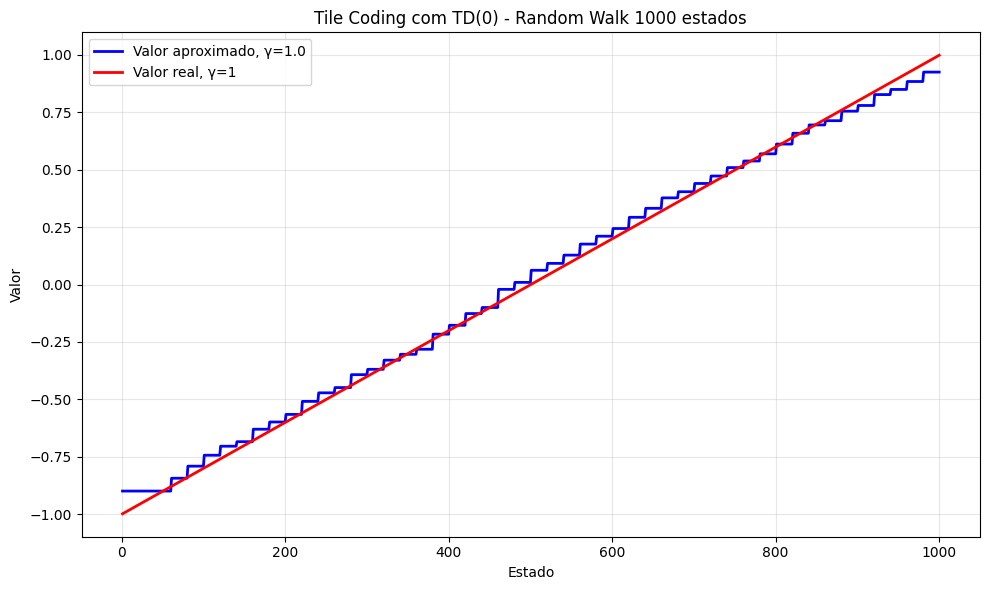

In [49]:
plt.figure(figsize=(10, 6))

x_states = np.arange(1, num_states-1)   

approx_values = [vFunc.value(s) for s in x_states]


real_values = true_values[1:-1]

plt.plot(x_states, approx_values, 'b-', linewidth=2, label=f'Valor aproximado, γ={rw.gamma}')
plt.plot(x_states, real_values, 'r-', linewidth=2, label='Valor real, γ=1')

plt.xlabel('Estado')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Tile Coding com TD(0) - Random Walk 1000 estados')
plt.tight_layout()
plt.show()
